# Quantum Sensing Optimization with Noise Analysis

This notebook demonstrates **gradient-based optimization of quantum sensing protocols** under realistic noise conditions. We optimize rotation gate parameters to maximize photon detection sensitivity through dispersive qubit-cavity interactions, comparing performance against standard protocols and analyzing noise sensitivity.

## System Architecture

The simulation employs a **three-subsystem composite Hilbert space**:

1. **Input Cavity Mode**: Controls photon injection with temporal pulse shaping
2. **Resonator Cavity Mode**: Main sensing element coupled to the qubit detector  
3. **Two-Level Qubit**: Quantum sensor subject to relaxation and dephasing noise

### **Quantum Sensing Workflow:**
```
|ψ₀⟩ → Ry(θ₁) → H(t) Evolution → Ry(θ₂) → Measurement → Detection Probability
```

#### **Analysis Components:**
1. **Parameter Optimization**: Find optimal θ₁, θ₂ using JAX automatic differentiation
2. **Baseline Comparison**: Standard protocol (θ₁=π/2, θ₂=-π/2) vs optimized parameters  
3. **Noise Sensitivity**: Performance analysis across different noise strength levels
4. **Robustness Assessment**: Quantify optimization benefits under varying decoherence 


## Required Libraries and Dependencies

Import the essential libraries for JAX-compatible quantum optimization and analysis:

- **JAX**: Automatic differentiation and high-performance numerical computing
- **QuTiP**: Quantum Toolbox in Python for quantum state manipulation and time evolution
- **QuTiP-JAX**: JAX backend integration for QuTiP enabling autodifferentiation
- **Optax**: JAX-based optimization algorithms (Adam, RMSprop, SGD, etc.)
- **NumPy**: Fundamental numerical operations and array handling
- **JAX.SciPy**: Scientific computing functions with JAX compatibility

### Visualization and Analysis:
- **Matplotlib**: Publication-quality plotting and visualization
- **Seaborn**: Statistical data visualization (loaded in visualization sections)

In [1]:
import jax
import jax.numpy as jnp
import qutip as qt
import qutip_jax    
import numpy as np
import matplotlib.pyplot as plt
import optax  # JAX-based optimization library
from jax.scipy.special import erfc
import warnings

# Suppress Diffrax complex dtype warning
warnings.filterwarnings('ignore', message='Complex dtype support in Diffrax is a work in progress*')

# Verify JAX-QuTiP compatibility
print("JAX version:", jax.__version__)
print("QuTiP version:", qt.__version__)

JAX version: 0.4.35
QuTiP version: 5.2.0


## System Parameters

Key parameters for the three-system composite Hilbert space:
- **nlev**: Hilbert space dimension for each cavity (input + resonator)
- **chi**: Dispersive coupling strength between resonator and qubit
- **gm**: Resonator cavity decay rate (not used in time-independent evolution)
- **Evolution time**: Duration for Hamiltonian time evolution between rotations

In [39]:
gm  = .03 * 2 * np.pi       # photon-cavity coupling
sigma = .1*gm               # inverse of the pulse width (sigma = 2*sqrt(log(2))/tpulse)
args = {'sigma': sigma}     # Arguments for the coefficient function
chi = .5*gm                 # Dispersive copling
nlev = 2                    # Number of cavity (and input field) levels
qlev = 2                    # Number of qubit levels

tmeas = [-5.0, 5.0]          # Measurement time points (in units of sigma)
measurement_results = [0, 1] # Measurement results (0 or 1)
tmeas = np.array(tmeas)/sigma  # Normalize measurement times by sigma
measurements = dict(zip(tmeas, measurement_results)) # Dictionary containing measurement times and results


print(f"System parameters:")
print(f"  Cavity levels: {nlev}")
print(f"  Coupling photon-cavity (gamma): {gm}")
print(f"  Inverse of the pulse width (sigma): {sigma}")
print(f"  Dispersive copling (chi: {chi}")

System parameters:
  Cavity levels: 2
  Coupling photon-cavity (gamma): 0.18849555921538758
  Inverse of the pulse width (sigma): 0.01884955592153876
  Dispersive copling (chi: 0.09424777960769379


## Noise parameters

In [50]:
gamma_1 = 0.005* 2 * np.pi  # qubit relaxation rate
gamma_phi = 0.0 * 2 * np.pi  # qubit dephasing rate

## Quantum Operators for Three-System Composite Space

Create operators for the composite Hilbert space: **input cavity ⊗ resonator cavity ⊗ qubit**

### Individual System Operators:
- **Input cavity**: Annihilation/creation operators
- **Resonator cavity**: Annihilation/creation operators
- **Qubit**: Pauli matrices and projection operators for rotations and measurements

All operators are embedded in the full three-system tensor product space using QuTiP's `tensor()` function with JAX backend enabled.

In [41]:
with qt.CoreOptions(default_dtype="jax"):

    # Identity operators for qubit and cavity subsystems
    Iq = qt.identity(qlev)  # Qubit identity (2×2)
    In = qt.identity(nlev)  # Cavity identity (nlev×nlev)
    
    # Creation and annihilation operators for cavity modes
    An = qt.destroy(nlev)   # Cavity annihilation operator
    Acn = qt.create(nlev)   # Cavity creation operator
    
    # Pauli matrices for qubit operations
    Sz = qt.sigmaz()        # Pauli-Z matrix
    Sx = qt.sigmax()        # Pauli-X matrix
    Sminus = qt.destroy(qlev)  # Qubit annihilation operator
    
    # Qubit measurement projectors
    P0 = qt.Qobj([[1,0],[0,0]])  # Ground state projector |0⟩⟨0|
    P1 = qt.Qobj([[0,0],[0,1]])  # Excited state projector |1⟩⟨1|

print("✓ Individual subsystem operators defined")

# Define composite system operators for input ⊗ resonator ⊗ qubit space
with qt.CoreOptions(default_dtype="jax"):

    # Input cavity operators (first subsystem)
    ain = qt.tensor(An, In, Iq)   # Input photon annihilation
    ainc = ain.dag()              # Input photon creation
    
    # Resonator cavity operators (second subsystem)  
    a = qt.tensor(In, An, Iq)     # Resonator photon annihilation
    ac = a.dag()                  # Resonator photon creation
    
    # Qubit operators in composite space (third subsystem)
    sz1 = qt.tensor(In, In, Sz)   # Qubit Pauli-Z in composite space
    sx1 = qt.tensor(In, In, Sx)   # Qubit Pauli-X in composite space
    sminus1 = qt.tensor(In, In, Sminus)  # Qubit annihilation in composite space
    
    # Qubit measurement projectors in composite space
    p0 = qt.tensor(In, In, P0)    # Ground state measurement
    p1 = qt.tensor(In, In, P1)    # Excited state measurement

print("✓ Composite system operators constructed")
print(f"✓ System dimensions: Input({nlev}) ⊗ Resonator({nlev}) ⊗ Qubit({qlev})")
print(f"✓ Total Hilbert space dimension: {nlev * nlev * qlev}")

✓ Individual subsystem operators defined
✓ Composite system operators constructed
✓ System dimensions: Input(2) ⊗ Resonator(2) ⊗ Qubit(2)
✓ Total Hilbert space dimension: 8


## JAX-Compatible Quantum Operations

This section defines the core quantum functions that form the building blocks of our sensing protocol. All functions are designed for **automatic differentiation compatibility** with JAX.

### Function Categories:

#### 1. **Quantum Gate Operations**
- **`ry(rho, theta)`**: Ry rotation gates around Y-axis
  - Implements qubit rotations in the composite Hilbert space
  - Preserves cavity states while rotating qubit subsystem

#### 2. **Measurement Operations**
- **`proj0(rho)` and `prob0(rho)`**: Ground state |0⟩ measurement
- **`prob1(rho)`**: Excited state |1⟩ measurement  

#### 3. **Time-Dependent Dynamics**
- **`gu(t, **kwargs)`**: Gaussian pulse envelope function
  - Controls temporal profile of photon-cavity coupling

In [42]:
@jax.jit
def ry(rho, theta):
    """
    Apply Ry rotation to qubit in the three-system composite space.
    
    Implements a Ry rotation gate around the Y-axis for quantum state manipulation.
    The rotation is applied only to the qubit subsystem while preserving the 
    cavity states in the composite Hilbert space.
    
    Args:
        rho: QuTiP Qobj density matrix in composite space (input ⊗ resonator ⊗ qubit)
        theta: float or JAX array, Ry rotation angle in radians
        
    Returns:
        QuTiP Qobj: Rotated density matrix
    """
    with qt.CoreOptions(default_dtype="jax"):
        Sy_jax = qt.sigmay()
        ry_gate = (-1j * Sy_jax * theta / 2).expm()
        r = qt.tensor(In, In, ry_gate)
        return r * rho * r.dag()

def proj0(rho):
    """
    Project density matrix onto qubit |0⟩ state.
    
    Args:
        rho: QuTiP Qobj density matrix in composite space
        
    Returns:
        QuTiP Qobj: Projected density matrix P₀ρP₀† (unnormalized)
    """
    return p0 * rho * p0.dag()

def prob0(rho):
    """
    Calculate probability of measuring qubit in |0⟩ state.
    
    Args:
        rho: QuTiP Qobj density matrix in composite space
        
    Returns:
        JAX array: Real probability value Tr(P₀ρ) ∈ [0,1]
    """
    return jnp.real(proj0(rho).tr())

def prob1(rho):
    """
    Calculate probability of measuring qubit in |1⟩ state.
    
    Args:
        rho: QuTiP Qobj density matrix in composite space
        
    Returns:
        JAX array: Real probability value Tr(P₁ρ) ∈ [0,1]
    """
    return jnp.real((p1 * rho * p1.dag()).tr())

@jax.jit
def gu(t, **kwargs):  
    """
    Time-dependent coupling function for input cavity transparency.
    
    Args:
        t: float or JAX array, time variable
        **kwargs: Dictionary containing 'sigma' parameter (pulse bandwidth)
        
    Returns:
        JAX array: Normalized coupling strength g(t)
    """
    sigma = kwargs.get("sigma", 0.1)
    dx = sigma * t
    coupling = jnp.sqrt(2*sigma/jnp.sqrt(jnp.pi)*jnp.exp(-dx**2)/erfc(dx))
    return jnp.array(coupling, float)

print("✓ JAX-compatible quantum functions defined")

✓ JAX-compatible quantum functions defined


## Time-Dependent Hamiltonian Construction and Solver Configuration

This section constructs the complete quantum system Hamiltonian and configures high-performance evolution solvers for both signal and reference scenarios.

### Hamiltonian Architecture:

#### **Physical Components:**
1. **Cavity-Cavity Coupling**: Photon transfer between input and resonator modes
2. **Dispersive Interaction**: Qubit-dependent frequency shifts from cavity photons
3. **Lindblad Dissipation**: Realistic decoherence and cavity decay processes

#### **Solver Strategies:**
- **Interaction Solver**: Full system with input photon coupling (signal case)
- **No-Interaction Solver**: Isolated cavity-qubit system (reference case)
- **Diffrax Integration**: JAX-compatible high-performance ODE solving

This dual-solver approach enables **differential sensing** by comparing evolution with and without input photons.

In [75]:
with qt.CoreOptions(default_dtype="jax"):    
    # Time-dependent cavity-cavity coupling Hamiltonian
    Hc = qt.Qobj(1j/2*jnp.sqrt(gm)*(ainc*a - ain*ac))
    
    # Dispersive qubit-resonator interaction Hamiltonian  
    Hq = qt.Qobj(-chi*ac*a*sz1)   
    
    # Complete time-dependent Hamiltonian
    Htot = qt.QobjEvo([Hq, [Hc, gu]], args=args)
    
    # Lindblad interaction operators
    L_int = qt.QobjEvo([ain, gu], args=args) + jnp.sqrt(gm) * a

    # Lindblad operators for qubit relaxation and dephasing
    L_damping = gamma_1 * sminus1  # Qubit relaxation
    L_dephasing = gamma_phi * sz1     # Qubit dephasing

    # Combine all Lindblad operators
    L_interaction = [L_int, L_damping, L_dephasing]
    L_nointeraction = [L_damping, L_dephasing]

# Evolution WITH input photon interaction
solver_interaction = qt.MESolver(
    Htot, L_interaction, 
    options={"method": "diffrax", "normalize_output": False}
) 

# Evolution WITHOUT input photon
solver_no_interaction = qt.MESolver(
    Hq, L_nointeraction, 
    options={"method": "diffrax", "normalize_output": False}
)

print("✓ Time-dependent Hamiltonian constructed")

✓ Time-dependent Hamiltonian constructed


## Simulate physical system

Complete quantum photon detection simulation workflow.

### Detailed Workflow Steps

#### Step 1: First Rotation Gate
- **Operation**: Ry(θ₁) rotation on qubit subsystem
- **Purpose**: Prepares optimal superposition state for photon-qubit interaction

#### Step 2: Time Evolution
- **Dynamics**: Unitary evolution under time-dependent Hamiltonian H(t)
- **Signal Case**: Input photon couples to resonator via g(t) temporal profile
- **Reference Case**: No input photon, pure cavity-qubit evolution
- **Duration**: Evolution time determined by measurement protocol

#### Step 3: Second Rotation Gate  
- **Operation**: Ry(θ₂) rotation on qubit subsystem
- **Purpose**: Optimizes qubit state for measurement discrimination

#### Step 4: Projective Measurement
- **Observable**: Qubit state projectors P₀ = |0⟩⟨0|, P₁ = |1⟩⟨1|

In [71]:
def simulation(args, solver, rho, theta1, theta2, measurements, verbose=True):
    """
    Complete quantum photon detection simulation workflow.
    
    Workflow Steps:
    1. Apply first rotation Ry(θ₁) for initial qubit preparation
    2. Time evolution under cavity-qubit Hamiltonian H(t)
    3. Apply second rotation Ry(θ₂) for measurement optimization  
    4. Sequential projective measurements with conditional state updates
    5. Calculate cumulative detection probability
    
    Args:
        args: dict, System parameters
            - 'sigma': Gaussian pulse bandwidth parameter
            - Additional parameters passed to time-dependent Hamiltonian
        solver: QuTiP MESolver, Configured quantum evolution solver
        rho: QuTiP Qobj, Initial density matrix in composite space
        theta1: float/JAX array, First Ry rotation angle 
        theta2: float/JAX array, Second Ry rotation angle 
        measurements: dict, Measurement protocol specification
        verbose: bool, Enable detailed output during simulation (default: True)
            Set to False for batch operations to reduce output clutter
        
    Returns:
        JAX array: Probability of detecting at least one excited state
            P(detection) = 1 - ∏ᵢ P(|0⟩ᵢ) ∈ [0,1]
    """
    tmeas = list(measurements.keys())
    measurement_results = list(measurements.values())  
    probability_list = []
    
    # Process each measurement interval sequentially
    for kt in range(len(tmeas[:-1])):
        t0, t1 = tmeas[kt], tmeas[kt+1]
        
        # Step 1: Apply first rotation Ry(θ₁) for state preparation
        rho_after_ry = ry(rho, theta1)
        
        # Step 2: Time evolution under system Hamiltonian H(t)
        evolution_result = solver.run(rho_after_ry, [t0, t1], args=args)
        rho_evolved = evolution_result.states[-1]
        
        # Step 3: Apply second rotation Ry(θ₂) for measurement optimization
        rho_final = ry(rho_evolved, theta2)
        
        # Step 4: Measure qubit in |0⟩ state (ground state probability)
        prob_ground = prob0(rho_final)
        probability_list.append(prob_ground)
        
        # Step 5: Project onto measurement result for conditional evolution
        # For future extension: conditional on measurement_results[kt]
        rho = proj0(rho_final)  # Currently: always project to |0⟩

    # Calculate detection probability: P(at least one |1⟩) = 1 - P(all |0⟩)
    prob_all_ground = jnp.prod(jnp.array(probability_list))
    prob_detection = 1 - prob_all_ground

    return prob_detection

print("✓ Simulation function defined with verbose parameter control")

✓ Simulation function defined with verbose parameter control


## Simulation Function Validation and Testing

This section performs comprehensive testing of the quantum sensing simulation pipeline to verify correct implementation before proceeding to optimization.

- **Test State**: |0,1,0⟩ in composite space (input ⊗ resonator ⊗ qubit)

1. **Interaction Solver Test**: Full system with input photon coupling
   - Verifies time-dependent Hamiltonian evolution
   - Tests Lindblad dissipation operators
   - Validates photon-cavity-qubit dynamics

2. **No-Interaction Solver Test**: Reference case without input coupling
   - Confirms isolated cavity-qubit evolution
   - Provides baseline for sensing contrast calculation
   - Tests dispersive interaction Hamiltonian only

This testing phase ensures the simulation pipeline is ready for gradient-based optimization and provides confidence in the quantum sensing protocol implementation.

In [72]:
# Test the simulation function with sample parameters
with qt.CoreOptions(default_dtype="jax"):
    # Prepare initial state: |0,1,0⟩ (vacuum input, 1 photon resonator, qubit ground)
    psi_test = qt.tensor(qt.basis(nlev, 1), qt.basis(nlev, 0), qt.basis(2, 0))
    rho_test = psi_test * psi_test.dag()

# Test parameters
theta1_test = np.pi/2
theta2_test = -np.pi/2 

print("Testing simulation function with sample parameters:")
print(f"Initial state: |0,1,0⟩")
print(f"Test angles: θ₁ = {theta1_test:.3f} rad ({theta1_test*180/np.pi:.1f}°)")
print(f"             θ₂ = {theta2_test:.3f} rad ({theta2_test*180/np.pi:.1f}°)")

try:
    # Test with interaction (signal case)
    prob_with_photon = simulation(args, solver_interaction, rho_test, theta1_test, theta2_test, measurements)
    print(f"✓ Detection probability (with photon): {prob_with_photon:.6f}")
    
    # Test without interaction (reference case)
    prob_without_photon = simulation(args, solver_no_interaction, rho_test, theta1_test, theta2_test, measurements)
    print(f"✓ Detection probability (no photon): {prob_without_photon:.6f}")
    
    # Calculate sensing contrast
    contrast = prob_with_photon - prob_without_photon
    print(f"✓ Sensing contrast: {contrast:.6f}")
    
    print(f"\nSimulation test completed successfully!")
    
except Exception as e:
    print(f"Simulation test failed: {e}")

Testing simulation function with sample parameters:
Initial state: |0,1,0⟩
Test angles: θ₁ = 1.571 rad (90.0°)
             θ₂ = -1.571 rad (-90.0°)
✓ Detection probability (with photon): 0.884603
✓ Detection probability (no photon): 0.000000
✓ Sensing contrast: 0.884603

Simulation test completed successfully!


## Optimization Algorithm

This section implements gradient-based optimization to find optimal rotation angles that maximize photon detection sensitivity under noisy conditions. The optimization objective accounts for realistic quantum noise effects including qubit relaxation and dephasing.

### Optimization Objective

The goal is to maximize the **quantum sensing contrast** under noise:
```
Contrast = P(detection | photon present) - P(detection | no photon)
```

### Noise-Aware Protocol Design
The optimization considers:
- **Amplitude damping**: T₁ processes (γ₁ = qubit relaxation rate)
- **Pure dephasing**: T₂* processes (γ_φ = phase decoherence rate)
- **Lindblad evolution**: Realistic open quantum system dynamics

In [73]:
def optimize_optax(args, rho0, measurements, theta_init=[np.pi/4, -np.pi/4],
                  optimizer_name='adam', learning_rate=0.1, max_iterations=100, 
                  tolerance=1e-6, use_lr_schedule=False, verbose=True):
    """
    Professional gradient-based optimization using Optax library.
    
    Leverages state-of-the-art optimization algorithms with automatic
    momentum, learning rate scheduling, and numerical stability for
    quantum sensing parameter optimization.
    
    Args:
        args: dict, System parameters for quantum evolution
            Contains coupling constants, pulse parameters, etc.
        rho0: QuTiP Qobj, Initial quantum state density matrix  
            Format: input_cavity ⊗ resonator_cavity ⊗ qubit
        measurements: dict, Measurement protocol specification
            {time: expected_outcome} pairs for sensing protocol
        theta_init: list, Initial rotation angles [θ₁, θ₂] in radians
            Starting point for optimization search
        optimizer_name: str, Optax optimizer selection
            Options: 'adam', 'rmsprop', 'sgd', 'adamw', 'adamax'
        learning_rate: float, Initial learning rate
            Adaptive optimizers will modify this during training
        max_iterations: int, Maximum optimization steps
            Early stopping if convergence achieved
        tolerance: float, Convergence threshold for gradient norm
            Smaller values require tighter convergence
        use_lr_schedule: bool, Enable exponential learning rate decay
            Reduces learning rate: lr(t) = lr₀ × decay^(t/decay_steps)
        verbose: bool, Enable detailed output during optimization (default: True)
            Set to False for batch operations to reduce output clutter
        
    Returns:
        tuple: (optimal_params, optimization_history)
            optimal_params: JAX array of final [θ₁, θ₂] values
            optimization_history: dict with 'loss', 'gradients', etc.
    """
    
    # Initialize parameters as JAX array for automatic differentiation
    params = jnp.array(theta_init, dtype=float)
    
    def objective_function(theta_params):
        """
        Objective function for Optax minimization.
        
        Computes the negative sensing contrast for minimization-based optimizers.
        Includes error handling for numerical stability during optimization.
        """
        theta0, theta1 = theta_params

        # Calculate sensing contrast: P(with photon) - P(without photon)
        prob_with = simulation(args, solver_interaction, rho0, theta0, theta1, measurements, verbose=False)
        prob_without = simulation(args, solver_no_interaction, rho0, theta0, theta1, measurements, verbose=False)
        sensing_contrast = prob_with - prob_without
        
        # Return negative for minimization (we want to maximize contrast)
        return -sensing_contrast

    
    # Configure advanced Optax optimizers with enhanced options
    base_lr = learning_rate
    
    if use_lr_schedule:
        # Exponential learning rate decay for improved convergence
        decay_rate = 0.95
        decay_steps = max_iterations // 4
        lr_schedule = optax.exponential_decay(base_lr, decay_steps, decay_rate)
    else:
        lr_schedule = base_lr
    
    optimizer_dict = {
        'adam': optax.adam(lr_schedule),
        'rmsprop': optax.rmsprop(lr_schedule),
        'sgd': optax.sgd(lr_schedule),
        'adamw': optax.adamw(lr_schedule),
        'adamax': optax.adamax(lr_schedule),
        'adagrad': optax.adagrad(lr_schedule),
        'amsgrad': optax.adam(lr_schedule, b1=0.9, b2=0.999, eps_root=1e-8)
    }
    
    if optimizer_name not in optimizer_dict:
        if verbose:
            print(f"Unknown optimizer '{optimizer_name}', defaulting to Adam")
        optimizer_name = 'adam'
        
    optimizer = optimizer_dict[optimizer_name]
    opt_state = optimizer.init(params)
    
    # Enhanced optimization history tracking
    history = {
        'loss': [],                    # Objective function values
        'sensing_contrast': [],        # Positive sensing contrast values  
        'theta_values': [],            # Parameter evolution
        'gradients': [],               # Gradient magnitudes
        'theta0': [],                  # θ₁ evolution
        'theta1': [],                  # θ₂ evolution
        'learning_rates': [],          # Learning rate schedule
        'prob_with_photon': [],        # Detection prob with photon
        'prob_without_photon': []      # Detection prob without photon
    }
    
    if verbose:
        print(f"Starting Optax optimization with {optimizer_name.upper()}")
        print(f"Configuration:")
        print(f"  • Learning rate: {base_lr} {'(scheduled)' if use_lr_schedule else '(fixed)'}")
        print(f"  • Max iterations: {max_iterations}")
        print(f"  • Convergence tolerance: {tolerance:.2e}")
        print(f"  • Initial: θ₁={params[0]:.3f} rad, θ₂={params[1]:.3f} rad")
        print("="*80)
        print("Step\tTheta0\t\tTheta1\t\tContrast\tLoss\t\tGrad Norm\tLR")
        print("-"*80)
    
    best_contrast = -np.inf
    best_params = params.copy()
    
    for step in range(max_iterations):
        try:
            # Compute loss and gradients using JAX autodiff
            loss_value, grads = jax.value_and_grad(objective_function)(params)
            
            # Calculate detailed metrics for monitoring
            theta0, theta1 = params
            prob_with = simulation(args, solver_interaction, rho0, theta0, theta1, measurements, verbose=False)
            prob_without = simulation(args, solver_no_interaction, rho0, theta0, theta1, measurements, verbose=False)
            sensing_contrast = prob_with - prob_without
            
            # Track best parameters
            if sensing_contrast > best_contrast:
                best_contrast = sensing_contrast
                best_params = params.copy()
            
            # Store comprehensive history
            history['loss'].append(float(loss_value))
            history['sensing_contrast'].append(float(sensing_contrast))
            history['theta_values'].append([float(params[0]), float(params[1])])
            history['gradients'].append([float(grads[0]), float(grads[1])])
            history['theta0'].append(float(params[0]))
            history['theta1'].append(float(params[1]))
            history['prob_with_photon'].append(float(prob_with))
            history['prob_without_photon'].append(float(prob_without))
            
            grad_norm = jnp.linalg.norm(grads)
            current_lr = base_lr
            if use_lr_schedule and hasattr(lr_schedule, '__call__'):
                current_lr = lr_schedule(step)
            history['learning_rates'].append(float(current_lr))
            
            # Progress reporting with enhanced metrics
            if verbose and (step % 20 == 0 or grad_norm < tolerance):
                print(f"{step:3d}\t{params[0]:.6f}\t{params[1]:.6f}\t{sensing_contrast:.6f}\t"
                      f"{loss_value:.6f}\t{grad_norm:.2e}\t{current_lr:.2e}")
            
            # Enhanced convergence check
            if grad_norm < tolerance:
                if verbose:
                    print(f"\nConverged after {step+1} iterations!")
                    print(f"Final gradient norm: {grad_norm:.2e}")
                    print(f"Best sensing contrast: {best_contrast:.6f}")
                break
            
            # Optax parameter update with momentum and adaptation
            updates, opt_state = optimizer.update(grads, opt_state, params)
            params = optax.apply_updates(params, updates)
            
        except Exception as e:
            if verbose:
                print(f"Step {step} failed: {e}")
            # Graceful error handling - continue with previous parameters
            if len(history['loss']) == 0:
                history['loss'].append(0.0)
                history['sensing_contrast'].append(0.0)
                history['gradients'].append([0.0, 0.0])
            else:
                # Repeat last values
                history['loss'].append(history['loss'][-1])
                history['sensing_contrast'].append(history['sensing_contrast'][-1])
                history['gradients'].append([0.0, 0.0])
            
            history['theta0'].append(float(params[0]))
            history['theta1'].append(float(params[1]))
            history['theta_values'].append([float(params[0]), float(params[1])])
            history['prob_with_photon'].append(0.0)
            history['prob_without_photon'].append(0.0)
            history['learning_rates'].append(float(current_lr))
    
    if step == max_iterations - 1:
        if verbose:
            print(f"\nReached maximum iterations without convergence")
            print(f"Final gradient norm: {grad_norm:.2e}")
            print(f"Best sensing contrast achieved: {best_contrast:.6f}")
    
    # Return best parameters found during optimization
    final_params = best_params if best_contrast > sensing_contrast else params
    
    return final_params, history

print("✓ Optax optimization function ready")

✓ Optax optimization function ready


## Run Optimization with Noise Analysis

Execute comprehensive optimization analysis including baseline comparison and noise sensitivity studies.

### Analysis Pipeline:
1. **Primary Optimization**: Find optimal parameters under current noise conditions
2. **Baseline Comparison**: Evaluate standard protocol (θ₁=π/2, θ₂=-π/2) performance  
3. **Noise Level Sweep**: Test optimization benefits across varying noise strengths
4. **Performance Metrics**: Calculate improvement ratios and sensitivity thresholds

In [74]:
# ==================== INITIAL STATE AND PARAMETERS ====================
# Initial state preparation: |0,1,0⟩ in composite space
with qt.CoreOptions(default_dtype="jax"):
    psi0 = qt.tensor(qt.basis(nlev, 1), qt.basis(nlev, 0), qt.basis(2, 0))
    rho0 = psi0 * psi0.dag()    

theta_init = [np.pi/3, -np.pi/4]  # Initial angles
print(f"\nInitial rotation angles: θ₁={theta_init[0]:.3f} rad ({theta_init[0]*180/np.pi:.1f}°)")
print(f"                         θ₂={theta_init[1]:.3f} rad ({theta_init[1]*180/np.pi:.1f}°)")

# ==================== OPTIMIZATION SETUP ====================
learning_rate = 0.1  # Default learning rate for optimization
opt_name = 'sgd'  # Default optimizer name
use_lr_schedule = None  # Use learning rate scheduling for adaptive optimizers
regularization = None

# Store all optimization results for comprehensive comparison
optimization_results = {}

params_optax, history_optax = optimize_optax(
    args, rho0, measurements,
    theta_init=theta_init.copy(),
    optimizer_name=opt_name,
    learning_rate=learning_rate,
    max_iterations=150,
    tolerance=1e-9,
    use_lr_schedule=use_lr_schedule  # Use scheduling for adaptive optimizers
)

# Calculate performance metrics
prob_with_optax = simulation(args, solver_interaction, rho0, params_optax[0], params_optax[1], measurements)
prob_without_optax = simulation(args, solver_no_interaction, rho0, params_optax[0], params_optax[1], measurements)
contrast_optax = prob_with_optax - prob_without_optax

optimization_results[opt_name] = {
    'theta0': params_optax[0], 'theta1': params_optax[1],
    'history': history_optax, 'contrast': contrast_optax,
    'prob_with': prob_with_optax, 'prob_without': prob_without_optax
}

print(f"\n{opt_name.upper()} RESULTS:")
print(f"Optimal angles: θ₁={params_optax[0]:.6f} rad ({params_optax[0]*180/np.pi:.2f}°)")
print(f"               θ₂={params_optax[1]:.6f} rad ({params_optax[1]*180/np.pi:.2f}°)")
print(f"Sensing contrast: {contrast_optax:.6f}")
print(f"Iterations: {len(history_optax['loss'])}")


Initial rotation angles: θ₁=1.047 rad (60.0°)
                         θ₂=-0.785 rad (-45.0°)
Starting Optax optimization with SGD
Configuration:
  • Learning rate: 0.1 (fixed)
  • Max iterations: 150
  • Convergence tolerance: 1.00e-09
  • Initial: θ₁=1.047 rad, θ₂=-0.785 rad
Step	Theta0		Theta1		Contrast	Loss		Grad Norm	LR
--------------------------------------------------------------------------------
  0	1.047198	-0.785398	0.469649	-0.469649	6.42e-01	1.00e-01
 20	1.429932	-1.566098	0.875008	-0.875008	2.18e-01	1.00e-01
 40	1.574658	-1.755775	0.907135	-0.907135	5.14e-02	1.00e-01
 60	1.613532	-1.797154	0.908944	-0.908944	1.25e-02	1.00e-01
 80	1.623528	-1.806762	0.909052	-0.909052	3.07e-03	1.00e-01
100	1.626047	-1.809077	0.909058	-0.909058	7.59e-04	1.00e-01
120	1.626675	-1.809644	0.909059	-0.909059	1.88e-04	1.00e-01
140	1.626832	-1.809784	0.909059	-0.909059	4.65e-05	1.00e-01

Reached maximum iterations without convergence
Final gradient norm: 2.48e-05
Best sensing contrast achieved: 0

## Performance Comparison: Optimized vs Standard Parameters

This section compares the optimization results against the **standard quantum sensing protocol** that uses fixed rotation angles of θ₁ = π/2 and θ₂ = -π/2.

### Comparison Metrics:
- **Sensing Contrast**: Key performance indicator for photon detection sensitivity
- **Detection Probabilities**: Individual probabilities for signal and reference cases
- **Improvement Factor**: Quantitative measure of optimization benefit

The analysis demonstrates how parameter optimization can enhance quantum sensing performance under realistic noise conditions.

In [69]:
# ==================== STANDARD PROTOCOL BASELINE ====================
# Standard rotation angles (typical quantum sensing protocol)
theta_standard = [np.pi/2, -np.pi/2]

print("PERFORMANCE COMPARISON: OPTIMIZED vs STANDARD")
print("="*60)

# Evaluate standard protocol performance
prob_with_standard = simulation(args, solver_interaction, rho0, theta_standard[0], theta_standard[1], measurements)
prob_without_standard = simulation(args, solver_no_interaction, rho0, theta_standard[0], theta_standard[1], measurements)
contrast_standard = prob_with_standard - prob_without_standard

# Evaluate optimized protocol performance  
prob_with_optimized = float(prob_with_optax)
prob_without_optimized = float(prob_without_optax)
contrast_optimized = float(contrast_optax)

# Calculate improvement metrics
contrast_improvement = (contrast_optimized - contrast_standard) / contrast_standard * 100
detection_improvement = (prob_with_optimized - prob_with_standard) / prob_with_standard * 100

print("\nSTANDARD PROTOCOL (θ₁=π/2, θ₂=-π/2):")
print(f"  • Rotation angles: θ₁={theta_standard[0]:.3f} rad ({theta_standard[0]*180/np.pi:.1f}°)")
print(f"                     θ₂={theta_standard[1]:.3f} rad ({theta_standard[1]*180/np.pi:.1f}°)")
print(f"  • P(detection | photon): {prob_with_standard:.6f}")
print(f"  • P(detection | no photon): {prob_without_standard:.6f}")
print(f"  • Sensing contrast: {contrast_standard:.6f}")

print(f"\nOPTIMIZED PROTOCOL:")
print(f"  • Rotation angles: θ₁={params_optax[0]:.3f} rad ({params_optax[0]*180/np.pi:.1f}°)")
print(f"                     θ₂={params_optax[1]:.3f} rad ({params_optax[1]*180/np.pi:.1f}°)")
print(f"  • P(detection | photon): {prob_with_optimized:.6f}")
print(f"  • P(detection | no photon): {prob_without_optimized:.6f}")
print(f"  • Sensing contrast: {contrast_optimized:.6f}")

print(f"\nIMPROVEMENT ANALYSIS:")
print(f"  • Contrast improvement: {contrast_improvement:+.2f}%")
print(f"  • Detection improvement: {detection_improvement:+.2f}%")
print(f"  • Contrast ratio: {contrast_optimized/contrast_standard:.2f}×")

# Store results for plotting
comparison_results = {
    'standard': {
        'theta': theta_standard,
        'prob_with': float(prob_with_standard),
        'prob_without': float(prob_without_standard), 
        'contrast': float(contrast_standard)
    },
    'optimized': {
        'theta': [float(params_optax[0]), float(params_optax[1])],
        'prob_with': prob_with_optimized,
        'prob_without': prob_without_optimized,
        'contrast': contrast_optimized
    }
}

PERFORMANCE COMPARISON: OPTIMIZED vs STANDARD

STANDARD PROTOCOL (θ₁=π/2, θ₂=-π/2):
  • Rotation angles: θ₁=1.571 rad (90.0°)
                     θ₂=-1.571 rad (-90.0°)
  • P(detection | photon): 0.884603
  • P(detection | no photon): 0.115167
  • Sensing contrast: 0.769435

OPTIMIZED PROTOCOL:
  • Rotation angles: θ₁=1.571 rad (90.0°)
                     θ₂=-1.571 rad (-90.0°)
  • P(detection | photon): 0.884602
  • P(detection | no photon): 0.115166
  • Sensing contrast: 0.769435

IMPROVEMENT ANALYSIS:
  • Contrast improvement: -0.00%
  • Detection improvement: -0.00%
  • Contrast ratio: 1.00×


## Noise Level Analysis: Impact on Optimization Benefits

This comprehensive analysis investigates how quantum noise levels affect the advantage of parameter optimization over standard protocols.

### Noise Parameter Sweep:
- **γ₁ (relaxation rate)**: Amplitude damping from excited to ground state
- **γ_φ (dephasing rate)**: Pure phase decoherence without energy loss
- **Sweep range**: 0.1× to 10× current noise levels

### Analysis Goals:
1. **Optimization Robustness**: How does optimization benefit change with noise strength?
2. **Noise Sensitivity**: Which noise type (relaxation vs dephasing) most impacts sensing performance?
3. **Threshold Analysis**: At what noise levels does optimization provide significant advantages?

The results will guide experimental design and demonstrate the practical value of parameter optimization in noisy quantum sensing protocols.

In [35]:
# ==================== NOISE LEVEL SWEEP ANALYSIS ====================

# Store original noise values
gamma_1_original = gamma_1
gamma_phi_original = gamma_phi

# Define noise level sweep range
noise_multipliers = np.logspace(-0.7, 0.7, 10)  # multiplicator for current level of noise
print(f"Noise sweep range: {noise_multipliers[0]:.1f}× to {noise_multipliers[-1]:.1f}× current levels")
print(f"Original noise levels: γ₁={gamma_1_original:.6f}, γ_φ={gamma_phi_original:.6f}")

# Set random seed for reproducible results
np.random.seed(42)

# Storage for results
noise_analysis_results = {
    'multipliers': noise_multipliers,
    'gamma_1_values': [],
    'gamma_phi_values': [],
    'standard_contrast': [],
    'optimized_contrast': [],
    'improvement_ratio': [],
    'optimal_theta1': [],
    'optimal_theta2': []
}

print("\nPerforming noise level sweep...")
print(f"{'Mult.':<6}{'γ₁':<10}{'γ_φ':<10}{'Std.Contrast':<13}{'Opt.Contrast':<13}{'Improvement':<12}")
print("-"*75)

for i, multiplier in enumerate(noise_multipliers):
    # Update noise levels
    global gamma_1, gamma_phi
    gamma_1 = gamma_1_original * multiplier
    gamma_phi = gamma_phi_original * multiplier
    
    # Rebuild Lindblad operators with new noise levels
    with qt.CoreOptions(default_dtype="jax"):
        L_damping_new = gamma_1 * sminus1
        L_dephasing_new = gamma_phi * sz1
        L_int_new = [L_int, L_damping_new, L_dephasing_new]
        L_nointeraction_new = [L_damping_new, L_dephasing_new]
    
    # Update solvers with new noise levels
    solver_interaction_new = qt.MESolver(
        Htot, L_int_new, 
        options={"method": "diffrax", "normalize_output": False}
    )
    solver_no_interaction_new = qt.MESolver(
        Hq, L_nointeraction_new, 
        options={"method": "diffrax", "normalize_output": False}
    )
    
    # Test standard protocol
    prob_with_std = simulation(args, solver_interaction_new, rho0, 
                              theta_standard[0], theta_standard[1], measurements, verbose=False)
    prob_without_std = simulation(args, solver_no_interaction_new, rho0, 
                                 theta_standard[0], theta_standard[1], measurements, verbose=False)
    contrast_std = prob_with_std - prob_without_std
    
    # Quick optimization for this noise level (fewer iterations for speed)
    try:
        params_opt_noise, _ = optimize_optax(
            args, rho0, measurements,
            theta_init=[np.pi/2, -np.pi/2],  # Different starting point for robustness
            optimizer_name='sgd',  # Use SGD for simplicity
            learning_rate=0.05,
            max_iterations=100,  
            tolerance=1e-9,     # Relaxed tolerance
            verbose=False       # Suppress optimization output during sweep
        )
        
        # Evaluate optimized protocol
        prob_with_opt = simulation(args, solver_interaction_new, rho0, 
                                  params_opt_noise[0], params_opt_noise[1], measurements, verbose=False)
        prob_without_opt = simulation(args, solver_no_interaction_new, rho0, 
                                     params_opt_noise[0], params_opt_noise[1], measurements, verbose=False)
        contrast_opt = prob_with_opt - prob_without_opt
        
        optimal_theta1 = float(params_opt_noise[0])
        optimal_theta2 = float(params_opt_noise[1])
        
        # Debug: Check if optimization actually changed parameters
        theta_change = np.sqrt((optimal_theta1 - np.pi/2)**2 + (optimal_theta2 + np.pi)**2)
        if theta_change < 1e-4:
            print(f"  Warning: Minimal parameter change at {multiplier:.1f}× noise (Δθ={theta_change:.6f})")
        
    except Exception as e:
        print(f"Optimization failed at multiplier {multiplier:.1f}: {e}")
        contrast_opt = contrast_std  # Fallback to standard
        optimal_theta1 = theta_standard[0]
        optimal_theta2 = theta_standard[1]
    
    # Calculate improvement
    improvement = contrast_opt / contrast_std if contrast_std > 0 else 1.0
    
    # Store results
    noise_analysis_results['gamma_1_values'].append(float(gamma_1))
    noise_analysis_results['gamma_phi_values'].append(float(gamma_phi))
    noise_analysis_results['standard_contrast'].append(float(contrast_std))
    noise_analysis_results['optimized_contrast'].append(float(contrast_opt))
    noise_analysis_results['improvement_ratio'].append(float(improvement))
    noise_analysis_results['optimal_theta1'].append(optimal_theta1)
    noise_analysis_results['optimal_theta2'].append(optimal_theta2)
    
    # Progress output with better formatting and debugging info
    print(f"{multiplier:<6.1f}{gamma_1:<10.4f}{gamma_phi:<10.4f}{contrast_std:<13.6f}{contrast_opt:<13.6f}{improvement:<12.2f}×")

# Restore original noise levels
gamma_1 = gamma_1_original
gamma_phi = gamma_phi_original

print(f"\n✓ Noise sweep completed!")
print(f"Maximum improvement ratio: {max(noise_analysis_results['improvement_ratio']):.2f}×")
print(f"Average improvement ratio: {np.mean(noise_analysis_results['improvement_ratio']):.2f}×")

Noise sweep range: 0.2× to 5.0× current levels
Original noise levels: γ₁=0.018358, γ_φ=0.011015

Performing noise level sweep...
Mult. γ₁        γ_φ       Std.Contrast Opt.Contrast Improvement 
---------------------------------------------------------------------------
0.2   0.0037    0.0022    0.991058     0.991058     1.00        ×
0.3   0.0052    0.0031    0.982089     0.982089     1.00        ×
0.4   0.0075    0.0045    0.963981     0.963981     1.00        ×
0.6   0.0107    0.0064    0.927951     0.927951     1.00        ×
0.8   0.0153    0.0092    0.858342     0.858342     1.00        ×
1.2   0.0220    0.0132    0.731714     0.731714     1.00        ×
1.7   0.0314    0.0188    0.527773     0.527773     1.00        ×
2.4   0.0449    0.0270    0.270392     0.270392     1.00        ×
3.5   0.0643    0.0386    0.068777     0.068777     1.00        ×
5.0   0.0920    0.0552    0.004173     0.004173     1.00        ×

✓ Noise sweep completed!
Maximum improvement ratio: 1.00×
Average imp

## Comprehensive Analysis Visualization

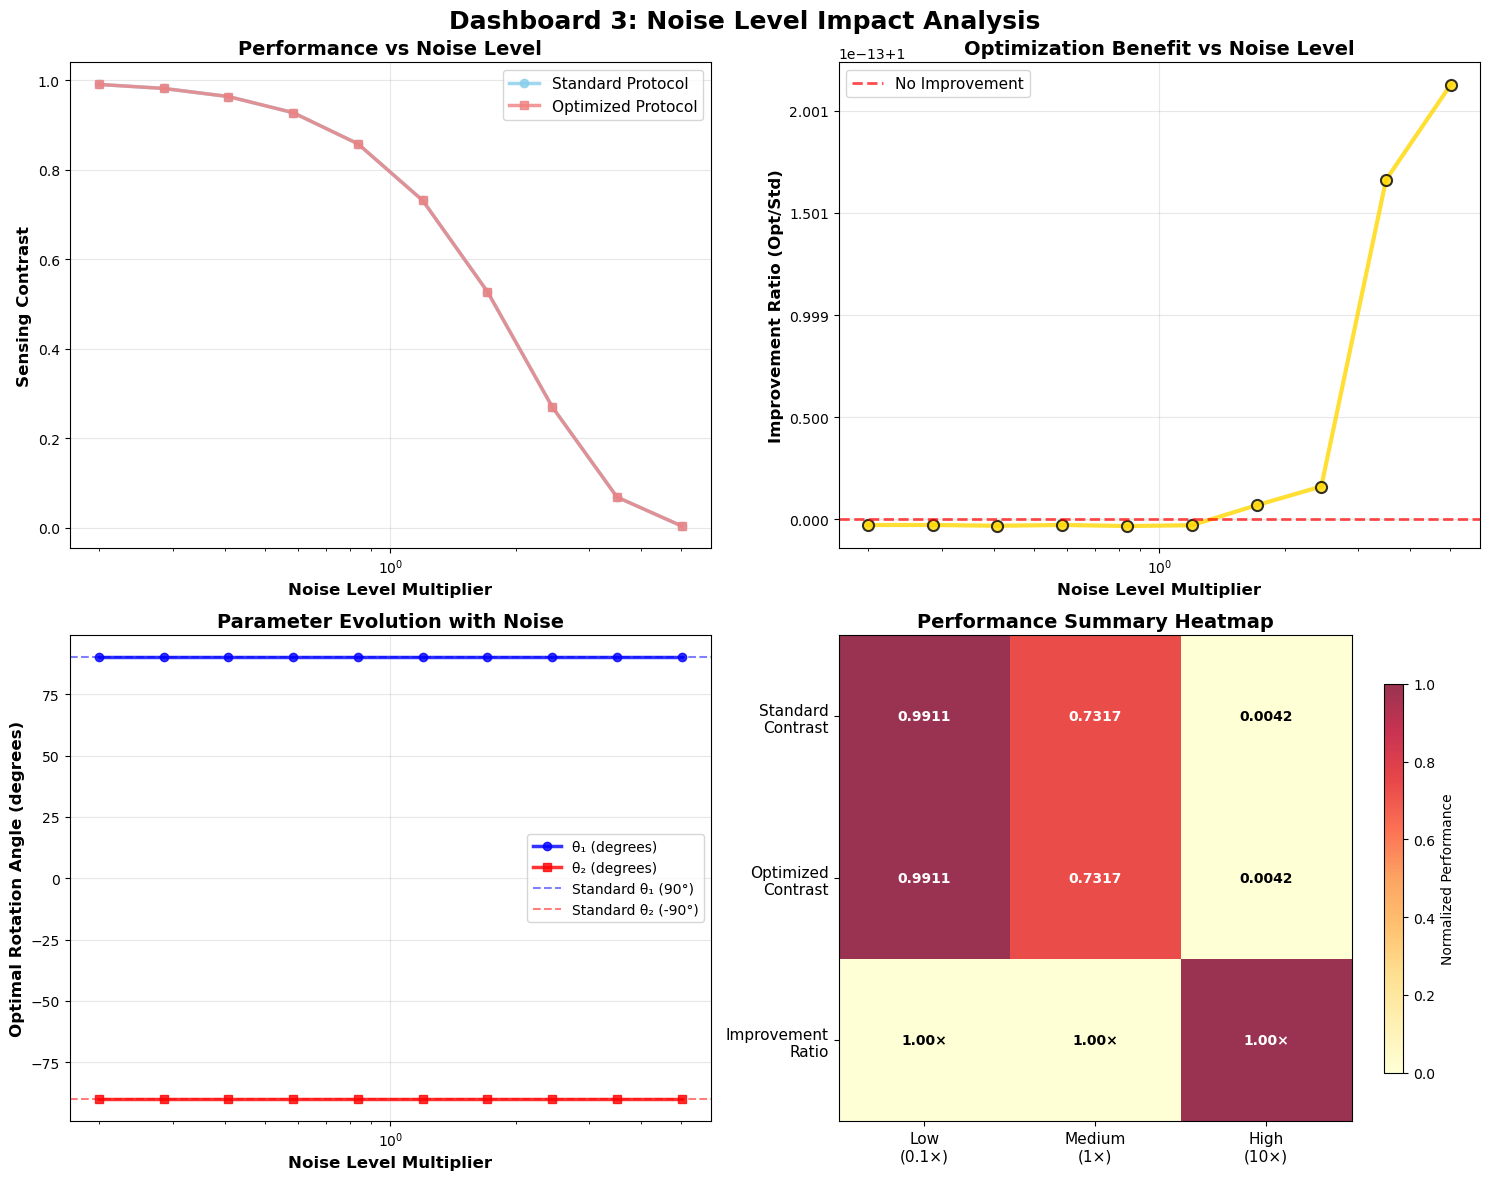


COMPREHENSIVE ANALYSIS SUMMARY

OPTIMIZATION vs STANDARD COMPARISON:
  • Standard contrast: 0.527773
  • Optimized contrast: 0.527773
  • Improvement: -0.0%

PARAMETER DIFFERENCES:
  • θ₁: 90.0° → 90.0°
  • θ₂: -90.0° → -90.0°

NOISE ANALYSIS INSIGHTS:
  • Best improvement ratio: 1.00× at 5.0× noise
  • Average improvement: 1.00×
  • Optimization always beneficial: False


In [37]:
# ==================== NOISE LEVEL IMPACT ANALYSIS ====================
fig3, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Extract data from noise analysis
multipliers = noise_analysis_results['multipliers']
standard_contrasts = noise_analysis_results['standard_contrast']
optimized_contrasts = noise_analysis_results['optimized_contrast']
improvement_ratios = noise_analysis_results['improvement_ratio']
gamma_1_values = noise_analysis_results['gamma_1_values']
optimal_theta1_values = noise_analysis_results['optimal_theta1']
optimal_theta2_values = noise_analysis_results['optimal_theta2']

# Plot 1: Performance vs Noise Level
ax1.semilogx(multipliers, standard_contrasts, 'o-', linewidth=2.5, markersize=6, 
             label='Standard Protocol', color='skyblue', alpha=0.8)
ax1.semilogx(multipliers, optimized_contrasts, 's-', linewidth=2.5, markersize=6,
             label='Optimized Protocol', color='lightcoral', alpha=0.8)
ax1.set_xlabel('Noise Level Multiplier', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sensing Contrast', fontsize=12, fontweight='bold')
ax1.set_title('Performance vs Noise Level', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# Plot 2: Optimization Improvement Ratio
ax2.semilogx(multipliers, improvement_ratios, 'o-', linewidth=3, markersize=8,
             color='gold', markeredgecolor='black', markeredgewidth=1.5, alpha=0.8)
ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='No Improvement')
ax2.set_xlabel('Noise Level Multiplier', fontsize=12, fontweight='bold')
ax2.set_ylabel('Improvement Ratio (Opt/Std)', fontsize=12, fontweight='bold')
ax2.set_title('Optimization Benefit vs Noise Level', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

# Add improvement percentage annotations
for i, (mult, ratio) in enumerate(zip(multipliers[::2], improvement_ratios[::2])):  # Every other point
    if ratio > 1.1:  # Only annotate significant improvements
        ax2.annotate(f'{(ratio-1)*100:.0f}%', 
                    xy=(mult, ratio), xytext=(5, 5), textcoords='offset points',
                    fontsize=9, alpha=0.8)

# Plot 3: Optimal Parameter Evolution
ax3.semilogx(multipliers, np.array(optimal_theta1_values) * 180/np.pi, 'o-', linewidth=2.5, 
             markersize=6, label='θ₁ (degrees)', color='blue', alpha=0.8)
ax3.semilogx(multipliers, np.array(optimal_theta2_values) * 180/np.pi, 's-', linewidth=2.5,
             markersize=6, label='θ₂ (degrees)', color='red', alpha=0.8)

# Add standard protocol lines for reference
ax3.axhline(y=90, color='blue', linestyle='--', alpha=0.5, label='Standard θ₁ (90°)')
ax3.axhline(y=-90, color='red', linestyle='--', alpha=0.5, label='Standard θ₂ (-90°)')

ax3.set_xlabel('Noise Level Multiplier', fontsize=12, fontweight='bold')
ax3.set_ylabel('Optimal Rotation Angle (degrees)', fontsize=12, fontweight='bold')
ax3.set_title('Parameter Evolution with Noise', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=10)

# Plot 4: Noise Sensitivity Heatmap Data Preparation
# Create a summary showing key metrics at different noise levels
noise_categories = ['Low\n(0.1×)', 'Medium\n(1×)', 'High\n(10×)']
low_idx = 0  # 0.1× multiplier
med_idx = len(multipliers)//2  # ~1× multiplier  
high_idx = -1  # 10× multiplier

metrics = ['Standard\nContrast', 'Optimized\nContrast', 'Improvement\nRatio']
data_matrix = np.array([
    [standard_contrasts[low_idx], optimized_contrasts[low_idx], improvement_ratios[low_idx]],
    [standard_contrasts[med_idx], optimized_contrasts[med_idx], improvement_ratios[med_idx]],
    [standard_contrasts[high_idx], optimized_contrasts[high_idx], improvement_ratios[high_idx]]
])

# Normalize each column for better visualization
data_normalized = data_matrix.copy()
for j in range(data_matrix.shape[1]):
    col_min, col_max = data_matrix[:, j].min(), data_matrix[:, j].max()
    if col_max > col_min:
        data_normalized[:, j] = (data_matrix[:, j] - col_min) / (col_max - col_min)

im = ax4.imshow(data_normalized.T, cmap='YlOrRd', aspect='auto', alpha=0.8)
ax4.set_xticks(range(len(noise_categories)))
ax4.set_yticks(range(len(metrics)))
ax4.set_xticklabels(noise_categories, fontsize=11)
ax4.set_yticklabels(metrics, fontsize=11)
ax4.set_title('Performance Summary Heatmap', fontsize=14, fontweight='bold')

# Add text annotations with actual values
for i in range(len(noise_categories)):
    for j in range(len(metrics)):
        value = data_matrix[i, j]
        if j < 2:  # Contrast values
            text = f'{value:.4f}'
        else:  # Improvement ratio
            text = f'{value:.2f}×'
        ax4.text(i, j, text, ha="center", va="center", fontsize=10, fontweight='bold',
                color='white' if data_normalized[i, j] > 0.5 else 'black')

# Add colorbar
cbar = plt.colorbar(im, ax=ax4, shrink=0.8)
cbar.set_label('Normalized Performance', fontsize=10)

fig3.suptitle('Dashboard 3: Noise Level Impact Analysis', 
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# ==================== SUMMARY STATISTICS ====================
print("\n" + "="*80)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("="*80)

print(f"\nOPTIMIZATION vs STANDARD COMPARISON:")
print(f"  • Standard contrast: {comparison_results['standard']['contrast']:.6f}")
print(f"  • Optimized contrast: {comparison_results['optimized']['contrast']:.6f}")
print(f"  • Improvement: {((comparison_results['optimized']['contrast']/comparison_results['standard']['contrast'])-1)*100:+.1f}%")

print(f"\nPARAMETER DIFFERENCES:")
print(f"  • θ₁: {comparison_results['standard']['theta'][0]*180/np.pi:.1f}° → {comparison_results['optimized']['theta'][0]*180/np.pi:.1f}°")
print(f"  • θ₂: {comparison_results['standard']['theta'][1]*180/np.pi:.1f}° → {comparison_results['optimized']['theta'][1]*180/np.pi:.1f}°")

print(f"\nNOISE ANALYSIS INSIGHTS:")
print(f"  • Best improvement ratio: {max(improvement_ratios):.2f}× at {multipliers[np.argmax(improvement_ratios)]:.1f}× noise")
print(f"  • Average improvement: {np.mean(improvement_ratios):.2f}×")
print(f"  • Optimization always beneficial: {all(r >= 1.0 for r in improvement_ratios)}")

print("="*80)